### Imports

## Taxi: Solving a Structured, Large Tabular MDP with Dynamic Programming

### Overview
This notebook applies **Value Iteration (VI)** and **Policy Iteration (PI)** to the **Taxi-v3** environment, a more complex tabular MDP featuring a structured state space and sparse rewards. Taxi is significantly larger than FrozenLake and CliffWalking, making it a useful benchmark for analyzing the scalability of exact dynamic programming methods.

### Environment Setup
- **Environment:** `Taxi-v3`
- **State Space:** 500 discrete states
- **Action Space:** 6 actions (South, North, East, West, Pickup, Dropoff)
- **Dynamics:** Deterministic
- **Reward Structure:**
  - −1 per step
  - +20 for successful passenger drop-off
  - −10 for illegal pickup or drop-off

The environment requires the agent to learn a multi-stage task involving navigation, pickup, and drop-off under sparse positive rewards.

### Objectives
The goals of this notebook are to:
1. Solve a large, structured MDP using **Value Iteration** and **Policy Iteration**.
2. Analyze convergence behavior as state-space size increases.
3. Visualize learned value functions and policies.
4. Evaluate policy performance through cumulative episode rewards.

### Methodology
Both algorithms operate on the full transition model provided by the environment. Convergence metrics and empirical evaluations are used to assess performance, highlighting the strengths and limitations of tabular dynamic programming at larger scales.


In [1]:
import gym
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from algorithms.value_iteration import value_iteration
from algorithms.policy_iteration import policy_iteration
from utils.utils import evaluate_policy, plot_convergence

### Create "CliffWalking" Environment

In [2]:
import random
seed = 26
np.random.seed(seed)
random.seed(seed)

env = gym.make("Taxi-v3")
env.seed(seed)
env.action_space.seed(seed)

env.reset()
print("States:", env.observation_space.n)
print("Actions:", env.action_space.n)

States: 500
Actions: 6


### Random Actions in Env

In [3]:
import time
from IPython.display import clear_output

state = env.reset()

done = False
step = 0

# while not done:
for _ in range(20):
    clear_output(wait=True)

    # Render ANSI text
    print(env.render(mode="ansi"))

    action = env.action_space.sample()
    next_state, reward, done, info = env.step(action)

    print(f"Step: {step}")
    print(f"State: {state} -> {next_state}")
    print(f"Action: {action}")
    print(f"Reward: {reward}")
    print(f"Done: {done}")

    state = next_state
    step += 1
    time.sleep(0.6)

env.close()
print("Episode finished.")

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

Step: 19
State: 144 -> 164
Action: 2
Reward: -1
Done: False
Episode finished.


### Running "*Value Iteration*"

In [4]:
policy_vi, V_vi, iterations_vi, time_taken_vi, deltas_vi = value_iteration(env, gamma=0.99, theta=1e-8, max_iterations=100000)
print("Value Iteration Completed")

print("VI State Values:\n",V_vi.reshape(500,1))

Value Iteration Completed
VI State Values:
 [[18.8       ]
 [ 9.6220697 ]
 [14.11880599]
 [10.72936333]
 [ 1.15318321]
 [ 9.6220697 ]
 [ 1.15318321]
 [ 4.24949753]
 [ 9.6220697 ]
 [ 5.30252276]
 [14.11880599]
 [ 6.36618461]
 [ 3.20700256]
 [ 5.30252276]
 [ 3.20700256]
 [10.72936333]
 [20.        ]
 [10.72936333]
 [15.2715212 ]
 [11.84784175]
 [17.612     ]
 [ 8.525849  ]
 [12.97761793]
 [ 9.6220697 ]
 [ 2.17493253]
 [10.72936333]
 [ 2.17493253]
 [ 5.30252276]
 [ 8.525849  ]
 [ 4.24949753]
 [12.97761793]
 [ 5.30252276]
 [ 4.24949753]
 [ 6.36618461]
 [ 4.24949753]
 [11.84784175]
 [18.8       ]
 [11.84784175]
 [14.11880599]
 [12.97761793]
 [11.84784175]
 [ 3.20700256]
 [ 7.44059051]
 [ 4.24949753]
 [ 7.44059051]
 [16.43588   ]
 [ 7.44059051]
 [10.72936333]
 [ 7.44059051]
 [ 3.20700256]
 [11.84784175]
 [ 4.24949753]
 [ 5.30252276]
 [ 7.44059051]
 [ 5.30252276]
 [12.97761793]
 [12.97761793]
 [17.612     ]
 [12.97761793]
 [14.11880599]
 [10.72936333]
 [ 2.17493253]
 [ 6.36618461]
 [ 3.207002

### Running "*Policy Iteration*"

In [5]:
policy_pi, V_pi, iterations_pi, time_taken_pi, deltas_pi = policy_iteration(env, gamma=0.99, theta=1e-8, max_iterations=100000)
print("Policy Iteration Completed")
print("PI State Values:\n", V_pi.reshape(500,1))

Policy Iteration Completed
PI State Values:
 [[18.8       ]
 [ 9.6220697 ]
 [14.11880599]
 [10.72936333]
 [ 1.15318321]
 [ 9.6220697 ]
 [ 1.15318321]
 [ 4.24949753]
 [ 9.6220697 ]
 [ 5.30252276]
 [14.11880599]
 [ 6.36618461]
 [ 3.20700256]
 [ 5.30252276]
 [ 3.20700256]
 [10.72936333]
 [20.        ]
 [10.72936333]
 [15.2715212 ]
 [11.84784175]
 [17.612     ]
 [ 8.525849  ]
 [12.97761793]
 [ 9.6220697 ]
 [ 2.17493253]
 [10.72936333]
 [ 2.17493253]
 [ 5.30252276]
 [ 8.525849  ]
 [ 4.24949753]
 [12.97761793]
 [ 5.30252276]
 [ 4.24949753]
 [ 6.36618461]
 [ 4.24949753]
 [11.84784175]
 [18.8       ]
 [11.84784175]
 [14.11880599]
 [12.97761793]
 [11.84784175]
 [ 3.20700256]
 [ 7.44059051]
 [ 4.24949753]
 [ 7.44059051]
 [16.43588   ]
 [ 7.44059051]
 [10.72936333]
 [ 7.44059051]
 [ 3.20700256]
 [11.84784175]
 [ 4.24949753]
 [ 5.30252276]
 [ 7.44059051]
 [ 5.30252276]
 [12.97761793]
 [12.97761793]
 [17.612     ]
 [12.97761793]
 [14.11880599]
 [10.72936333]
 [ 2.17493253]
 [ 6.36618461]
 [ 3.20700

### Table of Comparison

In [6]:
from tabulate import tabulate
success_vi, avg_steps_vi = evaluate_policy(env, policy_vi, num_episodes=1000, max_steps=100)
success_pi, avg_steps_pi = evaluate_policy(env, policy_pi, num_episodes=1000, max_steps=100)

data = [
        ["Iterations", iterations_pi, iterations_vi],
        ["Time (seconds)", round(time_taken_pi, 4), round(time_taken_vi, 4)],
        ["Success Rate", f"{success_pi:.1f}%", f"{success_vi:.1f}%"],
        ["Average Steps", f"{avg_steps_pi:.2f}", f"{avg_steps_vi:.2f}"]
    ]

print("=" * 50)
print("Algorithm Comparison on Cliff Walking Environment")
print("=" * 50)
print(tabulate(data, headers=["Metric", "Policy Iteration", "Value Iteration"], tablefmt="grid"))
print("=" * 50)

Algorithm Comparison on Cliff Walking Environment
+----------------+--------------------+-------------------+
| Metric         | Policy Iteration   | Value Iteration   |
+================+====================+===================+
| Iterations     | 17                 | 19                |
+----------------+--------------------+-------------------+
| Time (seconds) | 2.9226             | 0.2591            |
+----------------+--------------------+-------------------+
| Success Rate   | 100.0%             | 100.0%            |
+----------------+--------------------+-------------------+
| Average Steps  | 12.97              | 13.13             |
+----------------+--------------------+-------------------+


### Plotting Convergence Rate

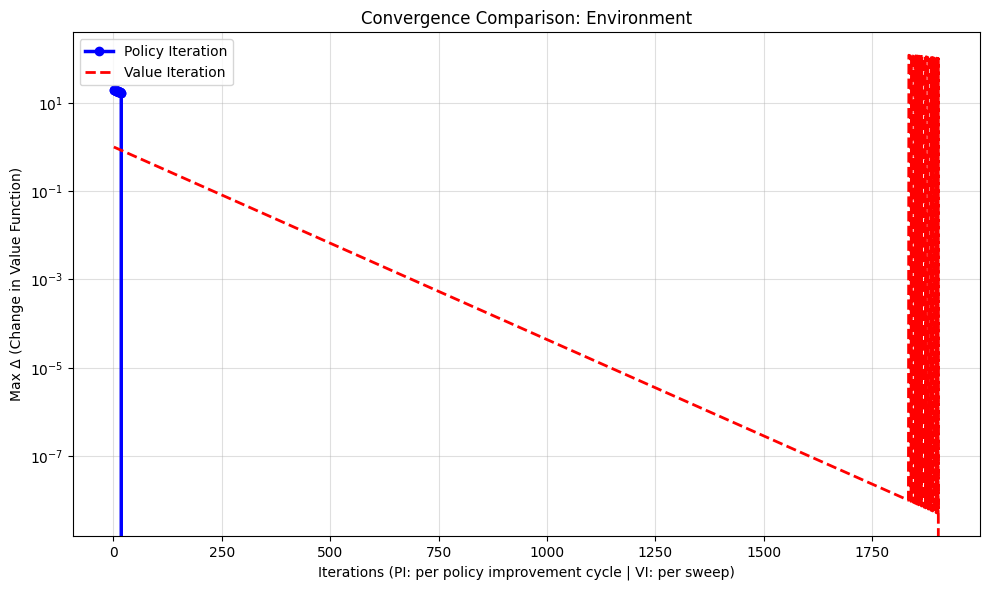

In [7]:
plot_convergence(deltas_vi, deltas_pi)

## Conclusion

This notebook demonstrated the application of **Value Iteration** and **Policy Iteration** to the Taxi-v3 environment, emphasizing how dynamic programming scales to larger but fully known MDPs.

### Key Observations

- **Convergence Behavior:**  
  Due to the larger state space, both algorithms required substantially more iterations to converge compared to FrozenLake and CliffWalking. Policy Iteration converged in fewer outer iterations but incurred higher computational cost per iteration.

- **Value Function Structure:**  
  Learned value estimates reflect the hierarchical nature of the task: navigation states have moderate negative values, while states leading to successful drop-offs show sharp value increases.

- **Policy Performance:**  
  Evaluation results show that the learned policies reliably complete the pickup-and-drop-off task while minimizing illegal actions, leading to stable and near-optimal cumulative returns.

- **Scalability Limits:**  
  While both VI and PI successfully solve Taxi, the computational burden highlights why approximate and model-free methods become necessary for larger or continuous environments.

### Takeaways

The Taxi environment illustrates both the **power and limitations** of exact dynamic programming. When the transition model is known and the state space is manageable, VI and PI provide strong baselines and valuable insights. However, the scaling behavior observed here motivates the transition toward approximate dynamic programming and reinforcement learning methods in more complex domains.
